# NuImages Segmentation Evaluation Tutorial


In [1]:
!pip install transformers

## Download model from Hugging Face

In [2]:
import json
from transformers import AutoImageProcessor

model_name = "tejasstanley/segformer-nuimages-b0-full-bs8"

processor = AutoImageProcessor.from_pretrained(model_name)
cfg = processor.to_dict()

pm_cfg = {
    "resize": {
        "height": cfg["size"]["height"],
        "width": cfg["size"]["width"],
    },
    "normalization": {
        "mean": list(cfg["image_mean"]),
        "std": list(cfg["image_std"]),
    },
    "ignored_classes": ["background", "vehicle.ego"],
}

model_cfg_path = "local/data/segformer_nuimages_b0_full_bs8_cfg.json"

with open(model_cfg_path, "w", encoding="utf-8") as f:
    json.dump(pm_cfg, f, indent=2)

/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/transformers/models/segformer/image_processing_segformer.py:99: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


## Build Dataset and Model Ontology



In [3]:
import json
from pathlib import Path

from perceptionmetrics.datasets.nuimages import NuImagesSegmentationDataset

dataset = NuImagesSegmentationDataset(
    dataset_dir="local/data/nuimages-v1.0-mini", version="v1.0-mini", split="val"
)

model_labels = {
    0: "animal",
    1: "human.pedestrian.adult",
    2: "human.pedestrian.child",
    3: "human.pedestrian.construction_worker",
    4: "human.pedestrian.personal_mobility",
    5: "human.pedestrian.police_officer",
    6: "human.pedestrian.stroller",
    7: "human.pedestrian.wheelchair",
    8: "movable_object.barrier",
    9: "movable_object.debris",
    10: "movable_object.pushable_pullable",
    11: "movable_object.trafficcone",
    12: "static_object.bicycle_rack",
    13: "vehicle.bicycle",
    14: "vehicle.bus.bendy",
    15: "vehicle.bus.rigid",
    16: "vehicle.car",
    17: "vehicle.construction",
    18: "vehicle.emergency.ambulance",
    19: "vehicle.emergency.police",
    20: "vehicle.motorcycle",
    21: "vehicle.trailer",
    22: "vehicle.truck",
    23: "flat.driveable_surface",
}

model_ontology = {
    class_name: {
        "idx": class_idx,
        "rgb": dataset.ontology[class_name]["rgb"],
    }
    for class_idx, class_name in model_labels.items()
}

model_ontology_path = Path("local/data/nuimages_model_ontology.json")
model_ontology_path.parent.mkdir(parents=True, exist_ok=True)
with open(model_ontology_path, "w", encoding="utf-8") as f:
    json.dump(model_ontology, f, indent=2)

print(f"Saved model ontology to {model_ontology_path}")
print("Dataset labels will be translated in memory during evaluation.")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Built nuImages segmentation dataset with 50 samples and 26 classes.
Saved model ontology to local/data/nuimages_model_ontology.json
Dataset labels will be translated in memory during evaluation.


## Initialize the PerceptionMetrics Model Wrapper



In [4]:
from transformers import SegformerForSemanticSegmentation
from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel

model_name = "tejasstanley/segformer-nuimages-b0-full-bs8"
model_cfg_path = "local/data/segformer_nuimages_b0_full_bs8_cfg.json"


hf_model = SegformerForSemanticSegmentation.from_pretrained(model_name)

pm_model = TorchImageSegmentationModel(
    model=hf_model,
    model_cfg=model_cfg_path,
    ontology_fname=str(model_ontology_path),
)

Torch detection not available
Tensorflow not available


/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any fe

## Inspect a Sample Prediction


Predicted class ids: [1, 3, 8, 11, 13, 16, 21, 22, 23]
Predicted class names: ['human.pedestrian.adult', 'human.pedestrian.construction_worker', 'movable_object.barrier', 'movable_object.trafficcone', 'vehicle.bicycle', 'vehicle.car', 'vehicle.trailer', 'vehicle.truck', 'flat.driveable_surface']
Dataset label ids in sample: [0, 4, 9, 17, 23, 24]
Dataset label names in sample: ['background', 'human.pedestrian.construction_worker', 'movable_object.barrier', 'vehicle.car', 'vehicle.truck', 'flat.driveable_surface']


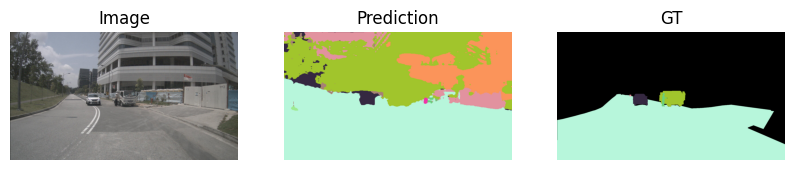

In [5]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

from perceptionmetrics.utils import conversion as uc

image_fname = dataset.dataset["image"].iloc[1]
if dataset.dataset_dir is not None:
    image_fname = Path(dataset.dataset_dir) / image_fname
image = Image.open(image_fname)

label_fname = dataset.dataset["label"].iloc[1]
if dataset.dataset_dir is not None:
    label_fname = Path(dataset.dataset_dir) / label_fname
label = Image.open(label_fname)
label = uc.label_to_rgb(label, dataset.ontology)

raw_pred = pm_model.predict(image)
raw_pred_np = np.array(raw_pred)
raw_label_np = np.array(Image.open(label_fname))

model_idx_to_name = {
    class_meta["idx"]: class_name for class_name, class_meta in pm_model.ontology.items()
}
dataset_idx_to_name = {
    class_meta["idx"]: class_name for class_name, class_meta in dataset.ontology.items()
}

pred_ids = sorted(np.unique(raw_pred_np).tolist())
label_ids = sorted(np.unique(raw_label_np).tolist())

print("Predicted class ids:", pred_ids)
print(
    "Predicted class names:",
    [model_idx_to_name.get(class_id, f"unknown:{class_id}") for class_id in pred_ids],
)
print("Dataset label ids in sample:", label_ids)
print(
    "Dataset label names in sample:",
    [dataset_idx_to_name.get(class_id, f"unknown:{class_id}") for class_id in label_ids],
)

pred = uc.label_to_rgb(raw_pred, pm_model.ontology)
pred = pred.resize(label.size)

plt.figure(figsize=(10, 10))
plt.subplot(131), plt.title("Image"), plt.imshow(np.array(image)), plt.axis("off")
plt.subplot(132), plt.title("Prediction"), plt.imshow(np.array(pred)), plt.axis("off")
plt.subplot(133), plt.title("GT"), plt.imshow(np.array(label)), plt.axis("off")
plt.show()

## Translate Dataset Labels and Run Evaluation

The evaluation call maps ground-truth labels from the nuImages ontology into the model ontology with `translation_direction="dataset_to_model"`.


In [6]:
# Translate original nuImages dataset labels into the model ontology.
# Classes ignored by the model config are masked before this translation is applied.
fallback_class = next(iter(pm_model.ontology.keys()))
dataset_to_model_translation = {
    class_name: (class_name if class_name in pm_model.ontology else fallback_class)
    for class_name in dataset.ontology.keys()
}

translation_path = Path("local/data/nuimages_to_model_ontology_translation.json")
translation_path.parent.mkdir(parents=True, exist_ok=True)
with open(translation_path, "w", encoding="utf-8") as f:
    json.dump(dataset_to_model_translation, f, indent=2)

results = pm_model.eval(
    dataset,
    split="val",
    ontology_translation=str(translation_path),
    translation_direction="dataset_to_model",
)
display(results)


100%|██████████| 50/50 [00:01<00:00, 35.81it/s]
/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:147: RuntimeWarning: invalid value encountered in divide
  return np.where(denominator > 0, tp / denominator, np.nan)
/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:164: RuntimeWarning: invalid value encountered in divide
  return np.where(denominator > 0, tp / denominator, np.nan)
/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:203: RuntimeWarning: invalid value encountered in divide
  denominator > 0, 2 * (precision * recall) / denominator, np.nan
/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:222: RuntimeWarning: invalid value encountered in divide


,animal,human.pedestrian.adult,human.pedestrian.child,human.pedestrian.construction_worker,human.pedestrian.personal_mobility,human.pedestrian.police_officer,human.pedestrian.stroller,human.pedestrian.wheelchair,movable_object.barrier,movable_object.debris,...,vehicle.car,vehicle.construction,vehicle.emergency.ambulance,vehicle.emergency.police,vehicle.motorcycle,vehicle.trailer,vehicle.truck,flat.driveable_surface,macro,micro
tp,0.0,4.578900e+04,0.0,2.280000e+02,0.000000e+00,0.0,0.0,0.0,7.052100e+04,0.000000e+00,...,3.026940e+05,1.243870e+05,0.0,0.0,2.299100e+04,6.436000e+03,7.031500e+04,2.559201e+06,NaN,NaN
fp,0.0,6.403000e+03,0.0,2.690000e+02,0.000000e+00,0.0,0.0,0.0,3.562000e+03,1.000000e+00,...,1.643800e+04,3.742000e+03,0.0,0.0,3.728000e+03,5.490000e+02,2.202200e+04,8.568000e+03,NaN,NaN
fn,0.0,5.353000e+03,0.0,1.494000e+03,1.254000e+03,0.0,0.0,0.0,3.064000e+03,1.146000e+03,...,1.231400e+04,3.680000e+03,0.0,0.0,1.579000e+03,1.489800e+04,9.345000e+03,9.131000e+03,NaN,NaN
tn,3326172.0,3.268627e+06,3326172.0,3.324181e+06,3.324918e+06,3326172.0,3326172.0,3326172.0,3.249025e+06,3.325025e+06,...,2.994726e+06,3.194363e+06,3326172.0,3326172.0,3.297874e+06,3.304289e+06,3.224490e+06,7.492720e+05,NaN,NaN
precision,NaN,8.773184e-01,NaN,4.587525e-01,NaN,NaN,NaN,NaN,9.519188e-01,0.000000e+00,...,9.484915e-01,9.707951e-01,NaN,NaN,8.604738e-01,9.214030e-01,7.615041e-01,9.966633e-01,0.789279,0.978781
recall,NaN,8.953306e-01,NaN,1.324042e-01,0.000000e+00,NaN,NaN,NaN,9.583611e-01,0.000000e+00,...,9.609089e-01,9.712650e-01,NaN,NaN,9.357346e-01,3.016781e-01,8.826889e-01,9.964448e-01,0.676058,0.978781
accuracy,1.0,9.964656e-01,1.0,9.994700e-01,9.996230e-01,1.0,1.0,1.0,9.980079e-01,9.996552e-01,...,9.913558e-01,9.977686e-01,1.0,1.0,9.984045e-01,9.953559e-01,9.905696e-01,9.946789e-01,0.998232,0.998232
f1_score,NaN,8.862330e-01,NaN,2.054980e-01,NaN,NaN,NaN,NaN,9.551291e-01,NaN,...,9.546599e-01,9.710300e-01,NaN,NaN,8.965275e-01,4.545358e-01,8.176305e-01,9.965540e-01,0.789115,0.978781
iou,NaN,7.957077e-01,NaN,1.145153e-01,0.000000e+00,NaN,NaN,NaN,9.141120e-01,0.000000e+00,...,9.132528e-01,9.436913e-01,NaN,NaN,8.124602e-01,2.941096e-01,6.915187e-01,9.931317e-01,0.617749,0.958443
dice_score,NaN,8.862330e-01,NaN,2.054980e-01,0.000000e+00,NaN,NaN,NaN,9.551291e-01,0.000000e+00,...,9.546599e-01,9.710300e-01,NaN,NaN,8.965275e-01,4.545358e-01,8.176305e-01,9.965540e-01,0.690476,0.978781
